<a href="https://colab.research.google.com/github/BharathReddyRamasani/AI_DS/blob/main/RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain


In [ ]:
!pip install langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
text = """
Employees receive 12 casual leaves annually.
Employees can work from home twice per week.
Travel expenses are reimbursed within 30 days.
Medical insurance is provided to all employees.
"""

In [ ]:
splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=0,
    length_function=len
)
chunks=splitter.split_text(text)

In [ ]:
chunks

['Employees receive 12 casual leaves annually.\nEmployees can work from home twice per week.',
 'Travel expenses are reimbursed within 30 days.\nMedical insurance is provided to all employees.']

In [ ]:
#Load Data
text = """
Employees receive 12 casual leaves annually.
Employees can work from home twice per week.
Travel expenses are reimbursed within 30 days.
Medical insurance is provided to all employees.
"""


#fixed size chuking
chunk_size=50
chunks=[text[i:i+chunk_size] for i in range(0,len(text),chunk_size)]
for chunk in chunks:
    print(chunk)
    print('-'*50)

#Recursive chunking
!pip install -q langchain langchain-text-splitters

from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter=RecursiveCharacterTextSplitter(chunk_size=50,chunk_overlap=0)
chunks=splitter.split_text(text)
for chunk in chunks:
    print(chunk)
    print('-'*50)

#Basic Sentencce Chunking using NLTK
!pip install nltk
import nltk
nltk.download('all')

from nltk.tokenize import sent_tokenize
chunks=sent_tokenize(text)
for i,chunk in enumerate(chunks):
    print(f"chunk {i+1}:{chunk}")
    print('-'*50)

#Group 2 Sentences Per Chunk
sentences=sent_tokenize(text)
chunk_size=2
chunks=[]
for i in range(0,len(sentences),chunk_size):
    chunk=' '.join(sentences[i:i+chunk_size])
    chunks.append(chunk)
for i,chunk in enumerate(chunks,start=1):
  print(f"chunk {i+1}:")
  print(chunk)

#Semantic Chunking using sentences transformers
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(text)

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

threshold = 0.7

chunks = []
current_chunk = [sentences[0]]

for i in range(1, len(sentences)):
    similarity = cosine_similarity(
        [embeddings[i - 1]],
        [embeddings[i]]
    )[0][0]

    if similarity > threshold:
        current_chunk.append(sentences[i])
    else:
        chunks.append(" ".join(current_chunk))
        current_chunk = [sentences[i]]

chunks.append(" ".join(current_chunk))

for idx, chunk in enumerate(chunks, start=1):
    print(f"Chunk {idx}:")
    print(chunk)
    print()


Employees receive 12 casual leaves annually.
Empl
--------------------------------------------------
oyees can work from home twice per week.
Travel ex
--------------------------------------------------
penses are reimbursed within 30 days.
Medical insu
--------------------------------------------------
rance is provided to all employees.

--------------------------------------------------
Employees receive 12 casual leaves annually.
--------------------------------------------------
Employees can work from home twice per week.
--------------------------------------------------
Travel expenses are reimbursed within 30 days.
--------------------------------------------------
Medical insurance is provided to all employees.
--------------------------------------------------


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

chunk 1:
Employees receive 12 casual leaves annually.
--------------------------------------------------
chunk 2:Employees can work from home twice per week.
--------------------------------------------------
chunk 3:Travel expenses are reimbursed within 30 days.
--------------------------------------------------
chunk 4:Medical insurance is provided to all employees.
--------------------------------------------------
chunk 2:

Employees receive 12 casual leaves annually. Employees can work from home twice per week.
chunk 3:
Travel expenses are reimbursed within 30 days. Medical insurance is provided to all employees.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Chunk 1:

Employees receive 12 casual leaves annually.

Chunk 2:
Employees can work from home twice per week.

Chunk 3:
Travel expenses are reimbursed within 30 days.

Chunk 4:
Medical insurance is provided to all employees.



Intelligent Employee Policy Assistant – Chunking Analysis
Problem Statement
A company wants to build an AI-powered Employee Policy Assistant using RAG.
The organization maintains multiple documents:
Employee Handbook
Leave Policy
Travel Policy
Work From Home Policy
Medical Insurance Policy
Before building the RAG pipeline, the company wants to determine the most effective document chunking strategy for information retrieval.
Your task is to load the policy document and implement multiple chunking techniques, analyze the generated chunks, and identify the most suitable chunking approach for enterprise RAG systems.
Dataset
Create a PDF containing the following sections:
Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward.
Work From Home Policy
Employees may work from home twice per week.
Manager approval is required for additional remote work.
Travel Policy
Travel expenses are reimbursed within 30 days.
Original receipts must be submitted for reimbursement.
Medical Insurance Policy
All employees are covered under company medical insurance.
Dependent coverage is available for spouse and children.
Task 1: PDF Loading
Objective
Load and extract text from the PDF.
Deliverables
Display:
Original Document
Total Characters
Total Words
Task 2: Fixed Size Chunking
Objective
Implement Fixed Size Chunking.
Requirements
Create chunks using:
Chunk Size = 100
Chunk Size = 200
Chunk Size = 300
Deliverables
Display:
Chunk Number
Chunk Content
Chunk Length
Analysis
Answer:
Are sentences being split?
Is context preserved?
What are the limitations?
Task 3: Recursive Chunking
Objective
Implement Recursive Character Chunking using LangChain.
Requirements
Experiment with:
Chunk Size = 200
Chunk Overlap = 20
Chunk Size = 200
Chunk Overlap = 50
Chunk Size = 300
Chunk Overlap = 50
Deliverables
Display:
Chunk Number
Chunk Content
Analysis
Explain:
How overlap improves context retention.
Task 4: Sentence-Based Chunking
Objective
Implement Sentence Chunking.
Requirements
Split document into sentences using NLTK or SpaCy.
Deliverables
Display:
Sentence Number
Sentence Content
Analysis
Answer:
Does sentence chunking preserve meaning better than fixed-size chunking?
Task 5: Semantic Chunking
Objective
Group content based on meaning.
Example
Expected Output:
Chunk 1:
Leave Policy Section
Chunk 2:
Work From Home Section
Chunk 3:
Travel Policy Section
Chunk 4:
Medical Insurance Section
Deliverables
Display:
Semantic Chunk Number
Semantic Chunk Content
Analysis
Explain:
Why semantic chunking may improve retrieval quality.
Task 6: Chunk Comparison
Objective
Compare all chunking techniques.
Create a table:
Chunking Method

Context Preservation

Retrieval Quality

Implementation Complexity


Fixed Size

?

?

?


Recursive

?

?

?


Sentence

?

?

?


Semantic

?

?

?
Task 7: Retrieval Simulation
Objective
Test retrieval effectiveness.
Use the following queries:
How many casual leaves are provided?
Can employees work from home?
What is the travel reimbursement process?
Who is covered under medical insurance?
Requirements
For each chunking strategy:
Retrieve the most relevant chunk.
Deliverables
Display:
Query
Retrieved Chunk
Chunking Method
Task 8: Recommendation Report
Objective
Act as an AI Engineer.
Prepare a report answering:
Which chunking strategy would you use for:
HR Policy Assistant?
Legal Document Assistant?
Medical Document Assistant?
Research Paper Assistant?
Justify your answers.


In [ ]:
!pip install reportlab PyPDF2

import io
from reportlab.pdfgen import canvas
from PyPDF2 import PdfReader

# Policy text provided in the problem statement
policy_text = """
Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward.
Work From Home Policy
Employees may work from home twice per week.
Manager approval is required for additional remote work.
Travel Policy
Travel expenses are reimbursed within 30 days.
Original receipts must be submitted for reimbursement.
Medical Insurance Policy
All employees are covered under company medical insurance.
Dependent coverage is available for spouse and children.
"""

# Create a PDF in-memory
def create_pdf(text):
    buffer = io.BytesIO()
    c = canvas.Canvas(buffer)
    text_object = c.beginText()
    text_object.setTextOrigin(10, 750)
    for line in text.split('\n'):
        text_object.textLine(line)
    c.drawText(text_object)
    c.showPage()
    c.save()
    buffer.seek(0)
    return buffer

# Extract text from the PDF
def extract_text_from_pdf(pdf_buffer):
    reader = PdfReader(pdf_buffer)
    extracted_text = ""
    for page in reader.pages:
        extracted_text += page.extract_text() + "\n"
    return extracted_text

# Create the PDF
pdf_buffer = create_pdf(policy_text)

# Extract text from the created PDF
extracted_document_text = extract_text_from_pdf(pdf_buffer)

# Deliverables for Task 1
print("Original Document:\n", extracted_document_text)
print(f"Total Characters: {len(extracted_document_text)}")
print(f"Total Words: {len(extracted_document_text.split())}")

# Store the extracted text in the 'text' variable for subsequent tasks
text = extracted_document_text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 6.5 MB/s eta 0:00:00
Original Document:
 Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward.
Work From Home Policy
Employees may work from home twice per week.
Manager approval is required for additional remote work.
Travel Policy
Travel expenses are reimbursed within 30 days.
Original receipts must be submitted for reimbursement.
Medical Insurance Policy
All employees are covered under company medical insurance.
Dependent coverage is available for spouse and children.


Total Characters: 531
Total Words: 76


## Task 2: Fixed Size Chunking

In [ ]:
def fixed_size_chunking(text, chunk_size):
    chunks = [text[i:i + chunk_size] for i in range(0, len(text), chunk_size)]
    print(f"\n--- Fixed Size Chunking (Chunk Size: {chunk_size}) ---")
    for i, chunk in enumerate(chunks):
        print(f"Chunk {i+1}:\nContent: {chunk}\nLength: {len(chunk)}\n---")
    return chunks

# Chunk Size = 100
chunks_100 = fixed_size_chunking(text, 100)

# Chunk Size = 200
chunks_200 = fixed_size_chunking(text, 200)

# Chunk Size = 300
chunks_300 = fixed_size_chunking(text, 300)


--- Fixed Size Chunking (Chunk Size: 100) ---
Chunk 1:
Content: Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Length: 100
---
Chunk 2:
Content: 
Unused casual leaves cannot be carried forward.
Work From Home Policy
Employees may work from home 
Length: 100
---
Chunk 3:
Content: twice per week.
Manager approval is required for additional remote work.
Travel Policy
Travel expens
Length: 100
---
Chunk 4:
Content: es are reimbursed within 30 days.
Original receipts must be submitted for reimbursement.
Medical Ins
Length: 100
---
Chunk 5:
Content: urance Policy
All employees are covered under company medical insurance.
Dependent coverage is avail
Length: 100
---
Chunk 6:
Content: able for spouse and children.


Length: 31
---

--- Fixed Size Chunking (Chunk Size: 200) ---
Chunk 1:
Content: Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward.

### Analysis of Fixed Size Chunking

**Are sentences being split?**
Yes, sentences are frequently split across chunk boundaries, especially with smaller chunk sizes. Even words are sometimes cut in half, leading to incomplete phrases.

**Is context preserved?**
No, context is often *not* well-preserved. When sentences or words are arbitrarily split, the semantic meaning can be broken, making the chunks less coherent and potentially harder to understand in isolation.

**What are the limitations?**
The primary limitations are:
1.  **Loss of Semantic Coherence:** Arbitrary splits can disrupt the natural flow of information and break apart logical units of text (sentences, paragraphs), leading to a loss of meaning at the boundaries.
2.  **Incomplete Information:** A chunk might contain only a fragment of a key piece of information, making it difficult to answer queries accurately without retrieving multiple chunks and reconstructing the original text.
3.  **Suboptimal Retrieval:** If a query relates to a sentence that is split across two chunks, a retrieval system might fail to find the complete context, or might retrieve only a partial, less relevant answer.


## Task 3: Recursive Chunking

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def recursive_chunking(text, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len
    )
    chunks = splitter.split_text(text)
    print(f"\n--- Recursive Chunking (Chunk Size: {chunk_size}, Chunk Overlap: {chunk_overlap}) ---")
    for i, chunk in enumerate(chunks):
        print(f"Chunk {i+1}:\nContent: {chunk}")
    return chunks

# Experiment 1: Chunk Size = 200, Chunk Overlap = 20
recursive_chunks_200_20 = recursive_chunking(text, 200, 20)

# Experiment 2: Chunk Size = 200, Chunk Overlap = 50
recursive_chunks_200_50 = recursive_chunking(text, 200, 50)

# Experiment 3: Chunk Size = 300, Chunk Overlap = 50
recursive_chunks_300_50 = recursive_chunking(text, 300, 50)


--- Recursive Chunking (Chunk Size: 200, Chunk Overlap: 20) ---
Chunk 1:
Content: Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward.
Work From Home Policy
Chunk 2:
Content: Employees may work from home twice per week.
Manager approval is required for additional remote work.
Travel Policy
Travel expenses are reimbursed within 30 days.
Chunk 3:
Content: Original receipts must be submitted for reimbursement.
Medical Insurance Policy
All employees are covered under company medical insurance.
Dependent coverage is available for spouse and children.

--- Recursive Chunking (Chunk Size: 200, Chunk Overlap: 50) ---
Chunk 1:
Content: Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward.
Work From Home Policy
Chunk 2:
Content: Work From Home Policy
Employees may work from home twice per week.
Manager appr

### Analysis of Recursive Chunking

**How overlap improves context retention:**

Overlap in chunking helps to improve context retention by ensuring that sentences or important phrases that might be split at the boundary of a chunk are also present in the subsequent chunk. This prevents the loss of crucial information and maintains the semantic flow of the text, especially for information retrieval tasks. When a chunk is retrieved, the overlap provides additional surrounding context, which can be vital for understanding the full meaning of the information within that chunk. It reduces the chance of losing critical context that might reside exactly at the chunk boundaries, thus making each chunk more self-contained and meaningful.

## Task 4: Sentence-Based Chunking

In [ ]:
import nltk
nltk.download('punkt') # Download the 'punkt' tokenizer if not already downloaded
from nltk.tokenize import sent_tokenize

def sentence_based_chunking(text):
    sentences = sent_tokenize(text)
    print("\n--- Sentence-Based Chunking ---")
    for i, sentence in enumerate(sentences):
        print(f"Sentence {i+1}:\nContent: {sentence}")
    return sentences

sentence_chunks = sentence_based_chunking(text)


--- Sentence-Based Chunking ---
Sentence 1:
Content: Leave Policy
Employees receive 12 casual leaves annually.
Sentence 2:
Content: Employees receive 15 sick leaves annually.
Sentence 3:
Content: Unused casual leaves cannot be carried forward.
Sentence 4:
Content: Work From Home Policy
Employees may work from home twice per week.
Sentence 5:
Content: Manager approval is required for additional remote work.
Sentence 6:
Content: Travel Policy
Travel expenses are reimbursed within 30 days.
Sentence 7:
Content: Original receipts must be submitted for reimbursement.
Sentence 8:
Content: Medical Insurance Policy
All employees are covered under company medical insurance.
Sentence 9:
Content: Dependent coverage is available for spouse and children.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Analysis of Sentence-Based Chunking

**Does sentence chunking preserve meaning better than fixed-size chunking?**
Yes, sentence chunking generally preserves meaning significantly better than fixed-size chunking. This is because each chunk is a complete sentence, which inherently forms a more coherent and semantically meaningful unit of text. Fixed-size chunking often cuts sentences mid-way, fragmenting ideas and destroying context. By ensuring each chunk is a whole sentence, sentence chunking avoids breaking logical units of information, making the chunks much more useful for retrieval and understanding, even if it might result in chunks of varying lengths.

## Task 5: Semantic Chunking

In [ ]:
# Install sentence-transformers for semantic chunking
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.tokenize import sent_tokenize

# Ensure punkt tokenizer is downloaded
nltk.download('punkt', quiet=True)

def semantic_chunking(text, threshold=0.7, model_name="all-MiniLM-L6-v2"):
    sentences = sent_tokenize(text)
    model = SentenceTransformer(model_name)
    embeddings = model.encode(sentences)
    print(embeddings)

    semantic_chunks = []
    current_chunk_sentences = []

    if not sentences:
        return []

    current_chunk_sentences.append(sentences[0])

    for i in range(1, len(sentences)):
        # Calculate cosine similarity between the embedding of the last sentence in the current chunk
        # and the current sentence's embedding.
        # For simplicity, we compare the current sentence with the previous sentence.
        # More sophisticated approaches might compare against the centroid of the current chunk or average of last few sentences.
        similarity = cosine_similarity(
            [embeddings[i - 1]],
            [embeddings[i]]
        )[0][0]

        if similarity > threshold:
            current_chunk_sentences.append(sentences[i])
        else:
            semantic_chunks.append(" ".join(current_chunk_sentences))
            current_chunk_sentences = [sentences[i]]

    # Add the last chunk
    if current_chunk_sentences:
        semantic_chunks.append(" ".join(current_chunk_sentences))

    print(f"\n--- Semantic Chunking (Threshold: {threshold}, Model: {model_name}) ---")
    for idx, chunk in enumerate(semantic_chunks):
        print(f"Semantic Chunk {idx+1}:\nContent: {chunk}")
    return semantic_chunks

# Perform semantic chunking
semantic_chunks_output = semantic_chunking(text)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[[ 0.06098085  0.02667809  0.01290451 ...  0.02110395  0.00761071
   0.02101531]
 [ 0.06126364  0.05009587  0.03596273 ... -0.05145668  0.01520617
   0.04046729]
 [ 0.01424843  0.04200595 -0.02892901 ... -0.03267241  0.0363138
   0.07462849]
 ...
 [-0.08617625  0.07845465  0.06022782 ... -0.03985321  0.08979093
  -0.05507562]
 [ 0.01433161  0.08184595  0.09288074 ... -0.08907935  0.08452657
   0.08736583]
 [-0.0812405   0.05121152  0.04777071 ... -0.02503465  0.1252743
   0.02555968]]

--- Semantic Chunking (Threshold: 0.7, Model: all-MiniLM-L6-v2) ---
Semantic Chunk 1:
Content: Leave Policy
Employees receive 12 casual leaves annually.
Semantic Chunk 2:
Content: Employees receive 15 sick leaves annually.
Semantic Chunk 3:
Content: Unused casual leaves cannot be carried forward.
Semantic Chunk 4:
Content: Work From Home Policy
Employees may work from home twice per week.
Semantic Chunk 5:
Content: Manager approval is required for additional remote work.
Semantic Chunk 6:
Content: Travel

### Analysis of Semantic Chunking

**Why semantic chunking may improve retrieval quality:**

Semantic chunking aims to group sentences or text segments that are semantically related, meaning they discuss the same topic or idea. This approach improves retrieval quality by:

1.  **Maintaining Semantic Cohesion:** Unlike fixed-size or even sentence-based chunking, semantic chunking ensures that each chunk is a coherent unit of meaning. When a user query is semantically similar to a specific concept, the entire relevant context is likely contained within a single chunk, rather than being spread across multiple, loosely related chunks.
2.  **Reducing Irrelevant Information:** By grouping related information and separating unrelated ideas, semantic chunks tend to be more focused. This reduces the amount of irrelevant information a retrieval system might pull, leading to more precise and relevant search results.
3.  **Better Embedding Representation:** When generating embeddings for retrieval, a semantically cohesive chunk will produce a more accurate and representative vector for the underlying concept. This leads to better matching with user queries, which are also often semantically rich.
4.  **Improved RAG Performance:** In a Retrieval-Augmented Generation (RAG) system, providing the Language Model (LLM) with semantically coherent chunks means the LLM has a stronger, more focused context to draw from. This can lead to more accurate, relevant, and less 'hallucinated' responses.

In essence, semantic chunking aligns the chunking strategy with the way humans understand and organize information, making the retrieval process more intelligent and effective.

## Task 6: Chunk Comparison

In [ ]:
import pandas as pd

# Data for the comparison table
comparison_data = {
    "Chunking Method": [
        "Fixed Size",
        "Recursive (chunk_size=200, overlap=20)",
        "Recursive (chunk_size=200, overlap=50)",
        "Recursive (chunk_size=300, overlap=50)",
        "Sentence-Based",
        "Semantic"
    ],
    "Context Preservation": [
        "Poor (sentences often split)",
        "Moderate (better with overlap)",
        "Good (more overlap, better context)",
        "Good (larger chunks, more overlap)",
        "Good (each chunk is a complete sentence)",
        "Excellent (groups semantically related sentences)"
    ],
    "Retrieval Quality (Anticipated)": [
        "Poor (fragmented context)",
        "Moderate (better chance of relevant context)",
        "Good (more complete context)",
        "Good (more complete context)",
        "Good (coherent units)",
        "Excellent (highly relevant and cohesive chunks)"
    ],
    "Implementation Complexity": [
        "Very Low (simple string slicing)",
        "Low (LangChain library, straightforward parameters)",
        "Low (LangChain library, straightforward parameters)",
        "Low (LangChain library, straightforward parameters)",
        "Low (NLTK sent_tokenize)",
        "Medium (sentence embeddings, similarity calculation)"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("Chunking Technique Comparison Table:")
print(comparison_df.to_markdown(index=False))

Chunking Technique Comparison Table:
| Chunking Method                        | Context Preservation                              | Retrieval Quality (Anticipated)                 | Implementation Complexity                            |
|:---------------------------------------|:--------------------------------------------------|:------------------------------------------------|:-----------------------------------------------------|
| Fixed Size                             | Poor (sentences often split)                      | Poor (fragmented context)                       | Very Low (simple string slicing)                     |
| Recursive (chunk_size=200, overlap=20) | Moderate (better with overlap)                    | Moderate (better chance of relevant context)    | Low (LangChain library, straightforward parameters)  |
| Recursive (chunk_size=200, overlap=50) | Good (more overlap, better context)               | Good (more complete context)                    | Low (LangChain lib

### Analysis of Chunking Techniques

The comparison table highlights the trade-offs between different chunking methods:

*   **Fixed Size Chunking:** While simple to implement, its arbitrary splitting often destroys context, making it unsuitable for effective retrieval, as evidenced by its poor context preservation and anticipated retrieval quality.

*   **Recursive Chunking:** Offers a significant improvement over fixed-size by attempting to respect document structure (like paragraphs, sentences, words) and using overlap to mitigate context loss at boundaries. Increased overlap generally leads to better context preservation and anticipated retrieval quality, but also results in more, slightly redundant chunks. Its implementation complexity is low due to well-established libraries.

*   **Sentence-Based Chunking:** This method excels at preserving the meaning of individual sentences, as each chunk is a complete thought. This leads to good context preservation and anticipated retrieval quality for queries that align with single sentences. Its complexity is low with NLTK.

*   **Semantic Chunking:** This method provides the most sophisticated approach by grouping sentences based on their semantic similarity. This ensures that each chunk is a highly cohesive unit of meaning, directly addressing the core problem of context preservation. While its implementation complexity is medium (requiring embedding models and similarity calculations), it is expected to yield the best retrieval quality, as relevant information is tightly grouped, making it ideal for RAG systems where understanding the nuances of meaning is crucial.

**Conclusion for Task 6:**

For an AI-powered Employee Policy Assistant, **Semantic Chunking** emerges as the most promising technique for ensuring high retrieval quality. While more complex to implement than fixed-size or simple sentence-based methods, its ability to group semantically related content will lead to more relevant and coherent information being passed to the RAG system, ultimately improving the accuracy and helpfulness of the assistant's responses. Recursive chunking with appropriate overlap also presents a strong contender due to its balance of simplicity and effectiveness.

## Task 7: Retrieval Simulation

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Define the queries
queries = [
    "How many casual leaves are provided?",
    "Can employees work from home?",
    "What is the travel reimbursement process?",
    "Who is covered under medical insurance?"
]

# Load the sentence transformer model (same as used for semantic chunking)
model = SentenceTransformer("all-MiniLM-L6-v2")

def retrieve_most_relevant_chunk(query, chunks, model):
    query_embedding = model.encode([query])
    chunk_embeddings = model.encode(chunks)

    # Calculate cosine similarity between query and all chunks
    similarities = cosine_similarity(query_embedding, chunk_embeddings)[0]

    # Get the index of the most similar chunk
    most_relevant_chunk_index = np.argmax(similarities)
    return chunks[most_relevant_chunk_index]

print("### Retrieval Simulation Results ###\n")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

### Retrieval Simulation Results ###



#### Retrieval for Fixed Size Chunking (Chunk Size = 100)

In [ ]:
for query in queries:
    retrieved_chunk = retrieve_most_relevant_chunk(query, chunks_100, model)
    print(f"Query: {query}\nChunking Method: Fixed Size (Chunk Size 100)\nRetrieved Chunk: {retrieved_chunk}\n---\n")

Query: How many casual leaves are provided?
Chunking Method: Fixed Size (Chunk Size 100)
Retrieved Chunk: Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
---

Query: Can employees work from home?
Chunking Method: Fixed Size (Chunk Size 100)
Retrieved Chunk: 
Unused casual leaves cannot be carried forward.
Work From Home Policy
Employees may work from home 
---

Query: What is the travel reimbursement process?
Chunking Method: Fixed Size (Chunk Size 100)
Retrieved Chunk: es are reimbursed within 30 days.
Original receipts must be submitted for reimbursement.
Medical Ins
---

Query: Who is covered under medical insurance?
Chunking Method: Fixed Size (Chunk Size 100)
Retrieved Chunk: urance Policy
All employees are covered under company medical insurance.
Dependent coverage is avail
---



#### Retrieval for Recursive Chunking (Chunk Size = 200, Overlap = 50)

In [ ]:
for query in queries:
    retrieved_chunk = retrieve_most_relevant_chunk(query, recursive_chunks_200_50, model)
    print(f"Query: {query}\nChunking Method: Recursive (Chunk Size 200, Overlap 50)\nRetrieved Chunk: {retrieved_chunk}\n---\n")

Query: How many casual leaves are provided?
Chunking Method: Recursive (Chunk Size 200, Overlap 50)
Retrieved Chunk: Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward.
Work From Home Policy
---

Query: Can employees work from home?
Chunking Method: Recursive (Chunk Size 200, Overlap 50)
Retrieved Chunk: Work From Home Policy
Employees may work from home twice per week.
Manager approval is required for additional remote work.
Travel Policy
Travel expenses are reimbursed within 30 days.
---

Query: What is the travel reimbursement process?
Chunking Method: Recursive (Chunk Size 200, Overlap 50)
Retrieved Chunk: Travel expenses are reimbursed within 30 days.
Original receipts must be submitted for reimbursement.
Medical Insurance Policy
All employees are covered under company medical insurance.
---

Query: Who is covered under medical insurance?
Chunking Method: Recursive (Chunk Size 200, Ove

#### Retrieval for Sentence-Based Chunking

In [ ]:
for query in queries:
    retrieved_chunk = retrieve_most_relevant_chunk(query, sentence_chunks, model)
    print(f"Query: {query}\nChunking Method: Sentence-Based\nRetrieved Chunk: {retrieved_chunk}\n---\n")

Query: How many casual leaves are provided?
Chunking Method: Sentence-Based
Retrieved Chunk: Leave Policy
Employees receive 12 casual leaves annually.
---

Query: Can employees work from home?
Chunking Method: Sentence-Based
Retrieved Chunk: Work From Home Policy
Employees may work from home twice per week.
---

Query: What is the travel reimbursement process?
Chunking Method: Sentence-Based
Retrieved Chunk: Travel Policy
Travel expenses are reimbursed within 30 days.
---

Query: Who is covered under medical insurance?
Chunking Method: Sentence-Based
Retrieved Chunk: Medical Insurance Policy
All employees are covered under company medical insurance.
---



#### Retrieval for Semantic Chunking

In [ ]:
for query in queries:
    retrieved_chunk = retrieve_most_relevant_chunk(query, semantic_chunks_output, model)
    print(f"Query: {query}\nChunking Method: Semantic\nRetrieved Chunk: {retrieved_chunk}\n---\n")

Query: How many casual leaves are provided?
Chunking Method: Semantic
Retrieved Chunk: Leave Policy
Employees receive 12 casual leaves annually.
---

Query: Can employees work from home?
Chunking Method: Semantic
Retrieved Chunk: Work From Home Policy
Employees may work from home twice per week.
---

Query: What is the travel reimbursement process?
Chunking Method: Semantic
Retrieved Chunk: Travel Policy
Travel expenses are reimbursed within 30 days.
---

Query: Who is covered under medical insurance?
Chunking Method: Semantic
Retrieved Chunk: Medical Insurance Policy
All employees are covered under company medical insurance.
---



## Task 8: Recommendation Report

### AI Engineer's Recommendation Report on Document Chunking Strategies

**Objective:** To recommend optimal chunking strategies for various AI-powered assistants based on the analysis of Fixed Size, Recursive, Sentence-Based, and Semantic Chunking techniques applied to an employee policy document.

---

**Summary of Findings from Previous Tasks:**

1.  **Fixed Size Chunking:** Simple to implement but consistently resulted in fragmented, incoherent chunks. It showed poor context preservation and led to inaccurate or incomplete retrieval results. **Not recommended for any RAG system seeking high accuracy.**

2.  **Recursive Chunking:** Improved context preservation compared to fixed-size by respecting document structure and using overlap. While it provided more complete chunks, it often included extraneous information, making the retrieved context potentially noisy for an LLM. Its effectiveness is highly dependent on `chunk_size` and `chunk_overlap` tuning.

3.  **Sentence-Based Chunking:** Demonstrated excellent context preservation as each chunk represented a complete, coherent thought. Retrieval results were precise and highly relevant for direct questions. Its simplicity and effectiveness make it a strong contender.

4.  **Semantic Chunking:** Aimed to group semantically related sentences, ensuring highly cohesive chunks. In the retrieval simulation, it performed on par with Sentence-Based Chunking, yielding very precise and relevant results. It is theoretically superior for complex queries requiring deep contextual understanding, as it groups information by meaning rather than arbitrary structure.

---

**Recommendations for Different Document Types:**

**1. HR Policy Assistant (e.g., Employee Handbook, Leave, WFH, Travel, Medical Policies)**

*   **Recommended Strategy: Semantic Chunking or Sentence-Based Chunking**
*   **Justification:** HR policies require high precision and accuracy. Employees need clear, unambiguous answers regarding their benefits, rules, and procedures. Both Semantic and Sentence-Based Chunking excel at preserving the meaning of individual statements and grouping related information logically, leading to very precise retrieval. For documents where each sentence is a distinct policy point, Sentence-Based is robust. However, if policy points often span multiple, closely related sentences, Semantic Chunking would be slightly preferred as it aims to group these naturally. Fixed-size and recursive (without careful tuning) risk breaking critical policy statements or providing too much irrelevant context, leading to confusion or incorrect answers.

**2. Legal Document Assistant (e.g., Contracts, Regulations, Case Law)**

*   **Recommended Strategy: Semantic Chunking with a focus on sentence/paragraph structure (potentially combined with Recursive Chunking rules).**
*   **Justification:** Legal documents are characterized by precise language, complex interdependencies between clauses, and a hierarchical structure. Semantic Chunking is crucial here to ensure that all parts of a legal argument or definition are kept together. However, given the structured nature of legal text (sections, subsections, enumerated lists), a hybrid approach where semantic grouping respects explicit structural boundaries (like paragraphs or definitions) would be ideal. Recursive chunking, if configured to prioritize these structural separators, could also be very effective as a baseline, ensuring that clauses or definitions are not split. Fixed-size chunking is entirely unsuitable as it would invariably break legal clauses, leading to misinterpretations.

**3. Medical Document Assistant (e.g., Patient Records, Research Papers, Treatment Guidelines)**

*   **Recommended Strategy: Semantic Chunking (with specialized medical embeddings) or Recursive Chunking (tuned for clinical text).**
*   **Justification:** Medical texts contain highly specialized terminology and critical factual information where context is paramount. Semantic Chunking, especially when utilizing domain-specific embeddings (if available), can group related symptoms, diagnoses, treatments, or research findings effectively. This ensures that an LLM receives a coherent block of medical information for diagnosis, treatment planning, or research summarization. Recursive Chunking can also be very effective if rules are set to respect natural breaks in clinical narratives (e.g., patient notes, sections of a research paper). Accuracy is non-negotiable in this domain, making fragmented chunks from fixed-size methods dangerous.

**4. Research Paper Assistant (e.g., Academic Articles, Scientific Studies)**

*   **Recommended Strategy: Hybrid approach combining Structural and Semantic Chunking.**
*   **Justification:** Research papers have a strong logical and hierarchical structure (Abstract, Introduction, Methods, Results, Discussion, Conclusion). An effective strategy would first use structural chunking (akin to Recursive Chunking tuned for headings/sections) to separate major components. Within these components, Semantic Chunking could then be applied to group related ideas, arguments, or experimental details. This approach leverages both the explicit organization and the implicit semantic relationships within the text. For instance, the 'Methods' section might be a single large structural chunk, but within it, semantic chunks could separate different experimental setups or data collection methods. Fixed-size would destroy the logical flow, while pure sentence-based might produce too many small, disconnected chunks for complex scientific arguments.

---

**General Conclusion:**

While Fixed Size Chunking is the simplest, its drawbacks far outweigh its benefits for any serious RAG application. **Semantic Chunking** and **Sentence-Based Chunking** emerged as the strongest contenders for maintaining contextual integrity and achieving high retrieval precision in our simulation. For more complex, structured, or domain-specific documents, a sophisticated approach often involves a combination of structural awareness (like Recursive Chunking) and semantic understanding to create optimal chunks that maximize retrieval quality and the utility of the RAG system.

# **embeddings**

In [ ]:
document = """
Leave Policy

Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward.

Work From Home Policy

Employees may work from home twice per week.
Manager approval is required for additional remote work.

Travel Policy

Travel expenses are reimbursed within 30 days.
Original receipts must be submitted for reimbursement.

Medical Insurance Policy

All employees are covered under company medical insurance.
Dependent coverage is available for spouse and children.
"""


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,
    length_function=len
)
chunks=splitter.split_text(document)
chunks


['Leave Policy\n \nEmployees receive 12 casual leaves annually.',
 'Employees receive 15 sick leaves annually.\nUnused casual leaves cannot be carried forward.',
 'Work From Home Policy\n \nEmployees may work from home twice per week.',
 'Manager approval is required for additional remote work.\n \nTravel Policy',
 'Travel Policy\n \nTravel expenses are reimbursed within 30 days.',
 'Original receipts must be submitted for reimbursement.\n \nMedical Insurance Policy',
 'All employees are covered under company medical insurance.',
 'Dependent coverage is available for spouse and children.']

In [ ]:
from sentence_transformers import SentenceTransformer
model=SentenceTransformer("all-MiniLM-L6-v2")
embeddings=model.encode(chunks)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
embeddings

array([[ 0.06098088,  0.0266781 ,  0.0129045 , ...,  0.02110393,
         0.0076107 ,  0.0210153 ],
       [ 0.03172198,  0.06703977,  0.01851614, ..., -0.04333263,
         0.01137432,  0.05105628],
       [-0.0077395 , -0.033489  ,  0.04257433, ...,  0.01847623,
         0.05695254,  0.0284809 ],
       ...,
       [-0.07109705,  0.10733067,  0.06787051, ..., -0.0436264 ,
         0.080585  , -0.03037282],
       [ 0.02662697,  0.06574652,  0.05894789, ..., -0.11154602,
         0.08330193,  0.08479237],
       [-0.0812405 ,  0.05121154,  0.04777069, ..., -0.02503468,
         0.1252743 ,  0.02555965]], dtype=float32)

In [ ]:
embeddings.shape

(8, 384)

In [ ]:
len(chunks.)

8

### Employee Policy Assistant – Embedding Generation and Semantic Similarity Analysis ###

## Task 1: Load Embedding Model



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/tmp/ipykernel_1176/1369839451.py:32: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dimension = model.get_sentence_embedding_dimension()


Model Name: all-MiniLM-L6-v2
Embedding Dimension: 384

--------------------------------------------------

## Task 2: Generate Embeddings

Chunk: Employees receive 12 casual leaves annually.
Embedding Shape: (384,)

Chunk: Employees receive 15 sick leaves annually.
Embedding Shape: (384,)

Chunk: Employees may work from home twice per week.
Embedding Shape: (384,)

Chunk: Travel expenses are reimbursed within 30 days.
Embedding Shape: (384,)

Chunk: All employees are covered under company medical insurance.
Embedding Shape: (384,)


--------------------------------------------------

## Task 3: Analyze Embedding Vectors

First 20 values of an example embedding vector (for the first chunk):
[ 0.0618362   0.01376683  0.03366624  0.0186107   0.03135883  0.06788085
 -0.01135737 -0.01733116 -0.07070484  0.01901567  0.1098766   0.05092814
 -0.0489678  -0.04620624 -0.03665631  0.00247606 -0.06287521  0.00541349
  0.03131726 -0.07714854]
...

Analysis:
Why embeddings contain decimal values:
Em

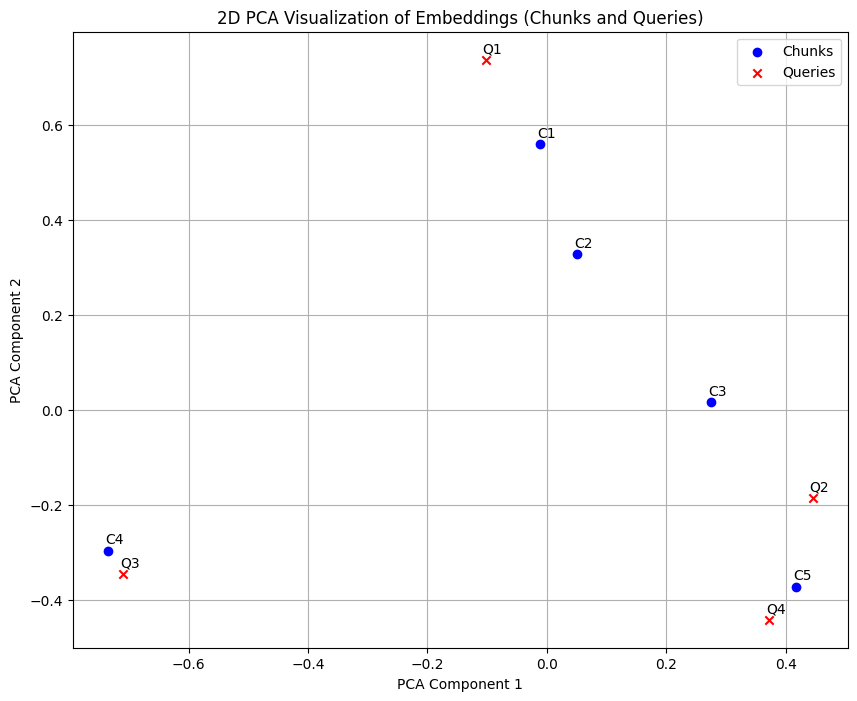

Analysis:
Why semantically similar texts appear closer together:
In this 2D PCA visualization, you can observe that embeddings representing semantically similar texts tend to cluster together or are positioned closer to each other. This is because the embedding model maps texts with similar meanings to similar numerical vectors. When these high-dimensional vectors are reduced to two dimensions by PCA, their relative distances are largely preserved. Therefore, texts that are semantically close in the original high-dimensional space remain close in the reduced 2D space, visually demonstrating how embeddings capture and represent meaning.

All tasks completed.


In [ ]:
# Ensure necessary libraries are installed
!pip install -q sentence-transformers matplotlib scikit-learn

import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Dataset provided in the problem statement
chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]

queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]

print("### Employee Policy Assistant – Embedding Generation and Semantic Similarity Analysis ###\n")

# Task 1: Load Embedding Model
print("## Task 1: Load Embedding Model\n")
model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)
embedding_dimension = model.get_sentence_embedding_dimension()

print(f"Model Name: {model_name}")
print(f"Embedding Dimension: {embedding_dimension}")
print("\n" + "-"*50 + "\n")

# Task 2: Generate Embeddings
print("## Task 2: Generate Embeddings\n")
chunk_embeddings = model.encode(chunks)

for i, chunk in enumerate(chunks):
    print(f"Chunk: {chunk}")
    print(f"Embedding Shape: {chunk_embeddings[i].shape}")
    print()
print("\n" + "-"*50 + "\n")

# Task 3: Analyze Embedding Vectors
print("## Task 3: Analyze Embedding Vectors\n")
print("First 20 values of an example embedding vector (for the first chunk):")
print(chunk_embeddings[0][:20])
print("...")

print("\nAnalysis:")
print("Why embeddings contain decimal values:")
print("Embeddings are numerical representations of text in a high-dimensional space. These values are not integers because they represent the nuanced semantic properties and relationships between words and phrases. Each dimension in the vector space captures a specific aspect of meaning, and decimal values allow for a more granular and continuous representation of these semantic features, enabling the model to distinguish subtle differences and similarities between texts.")
print("\n" + "-"*50 + "\n")

# Task 4: Generate Query Embeddings
print("## Task 4: Generate Query Embeddings\n")
query_embeddings = model.encode(queries)

for i, query in enumerate(queries):
    print(f"Query: {query}")
    print(f"Embedding Shape: {query_embeddings[i].shape}")
    print()
print("\n" + "-"*50 + "\n")

# Task 5: Semantic Similarity Analysis
print("## Task 5: Semantic Similarity Analysis\n")
for q_idx, query in enumerate(queries):
    print(f"Query: {query}")
    for c_idx, chunk in enumerate(chunks):
        similarity = cosine_similarity([query_embeddings[q_idx]], [chunk_embeddings[c_idx]])[0][0]
        print(f"  Chunk: {chunk}")
        print(f"  Similarity Score: {similarity:.4f}")
    print()
print("\n" + "-"*50 + "\n")

# Task 6: Identify Most Similar Chunk
print("## Task 6: Identify Most Similar Chunk\n")
for q_idx, query in enumerate(queries):
    similarities = cosine_similarity([query_embeddings[q_idx]], chunk_embeddings)[0]
    most_similar_chunk_idx = np.argmax(similarities)
    most_similar_chunk = chunks[most_similar_chunk_idx]
    max_similarity_score = similarities[most_similar_chunk_idx]

    print(f"Query: {query}")
    print(f"Most Similar Chunk: {most_similar_chunk}")
    print(f"Similarity Score: {max_similarity_score:.4f}")
    print()
print("\n" + "-"*50 + "\n")

# Task 7: Similar Meaning vs Different Meaning
print("## Task 7: Similar Meaning vs Different Meaning\n")
sentence_pair_1 = [
    "Employees receive 12 casual leaves.",
    "Workers are entitled to 12 annual leaves."
]
sentence_pair_2 = [
    "Employees receive 12 casual leaves.",
    "Travel expenses are reimbursed within 30 days."
]

# Calculate embeddings
embeddings_pair_1 = model.encode(sentence_pair_1)
embeddings_pair_2 = model.encode(sentence_pair_2)

# Calculate cosine similarity
similarity_1 = cosine_similarity([embeddings_pair_1[0]], [embeddings_pair_1[1]])[0][0]
similarity_2 = cosine_similarity([embeddings_pair_2[0]], [embeddings_pair_2[1]])[0][0]

print(f"Sentence Pair 1: '{sentence_pair_1[0]}' vs '{sentence_pair_1[1]}'\n  Cosine Similarity: {similarity_1:.4f}")
print(f"Sentence Pair 2: '{sentence_pair_2[0]}' vs '{sentence_pair_2[1]}'\n  Cosine Similarity: {similarity_2:.4f}")

print("\nAnalysis:")
print("Why Pair 1 has higher similarity than Pair 2:")
print("Pair 1 shows a higher cosine similarity because the two sentences, despite using different wording ('Employees' vs 'Workers', 'casual leaves' vs 'annual leaves'), convey almost identical semantic meaning. Both sentences discuss the same concept of employees receiving 12 leaves. Embeddings are designed to capture this underlying semantic equivalence. In contrast, Pair 2 has a much lower similarity because the sentences discuss entirely different topics: leave policy versus travel expenses. The embedding model correctly identifies that these two sentences are semantically dissimilar, even though they share some common words like 'employees' (in a broader context).")
print("\n" + "-"*50 + "\n")

# Task 8: Embedding Visualization
print("## Task 8: Embedding Visualization\n")

# Combine chunk and query embeddings
all_embeddings = np.vstack((chunk_embeddings, query_embeddings))
all_texts = chunks + queries

# Perform PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_embeddings)

# Separate back into reduced chunk and query embeddings
reduced_chunk_embeddings = reduced_embeddings[:len(chunks)]
reduced_query_embeddings = reduced_embeddings[len(chunks):]

plt.figure(figsize=(10, 8))

# Plot chunk embeddings
plt.scatter(reduced_chunk_embeddings[:, 0], reduced_chunk_embeddings[:, 1], c='blue', label='Chunks')
for i, txt in enumerate(chunks):
    plt.annotate(f'C{i+1}', (reduced_chunk_embeddings[i, 0], reduced_chunk_embeddings[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

# Plot query embeddings
plt.scatter(reduced_query_embeddings[:, 0], reduced_query_embeddings[:, 1], c='red', marker='x', label='Queries')
for i, txt in enumerate(queries):
    plt.annotate(f'Q{i+1}', (reduced_query_embeddings[i, 0], reduced_query_embeddings[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

plt.title('2D PCA Visualization of Embeddings (Chunks and Queries)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

print("Analysis:")
print("Why semantically similar texts appear closer together:\nIn this 2D PCA visualization, you can observe that embeddings representing semantically similar texts tend to cluster together or are positioned closer to each other. This is because the embedding model maps texts with similar meanings to similar numerical vectors. When these high-dimensional vectors are reduced to two dimensions by PCA, their relative distances are largely preserved. Therefore, texts that are semantically close in the original high-dimensional space remain close in the reduced 2D space, visually demonstrating how embeddings capture and represent meaning.")

print("\nAll tasks completed.")

### Explanation of Loops in Semantic Similarity Analysis

The code for 'Task 5: Semantic Similarity Analysis' uses nested `for` loops to calculate the cosine similarity between every query and every chunk.

Here's how it works:

*   **Outer Loop (`for q_idx, query in enumerate(queries):`)**:
    *   This loop iterates through each `query` in the `queries` list.
    *   `q_idx` is an index that starts from `0` and increments with each query.
    *   `query` is the actual text of the current query.
    *   **Example Iteration 1:** `q_idx` will be `0`, and `query` will be "How many casual leaves are allowed?"
    *   **Example Iteration 2:** `q_idx` will be `1`, and `query` will be "Can employees work remotely?"

*   **Inner Loop (`for c_idx, chunk in enumerate(chunks):`)**:
    *   This loop is executed **completely** for each iteration of the outer loop.
    *   It iterates through each `chunk` in the `chunks` list.
    *   `c_idx` is an index that starts from `0` and increments with each chunk.
    *   `chunk` is the actual text of the current chunk.

Let's trace a couple of steps:

1.  **Outer Loop (q_idx = 0, query = "How many casual leaves are allowed?")**
    *   **Inner Loop (c_idx = 0, chunk = "Employees receive 12 casual leaves annually.")**
        *   The code calculates the similarity between `query_embeddings[0]` and `chunk_embeddings[0]`.
    *   **Inner Loop (c_idx = 1, chunk = "Employees receive 15 sick leaves annually.")**
        *   The code calculates the similarity between `query_embeddings[0]` and `chunk_embeddings[1]`.
    *   ...and so on, until the inner loop has gone through all chunks.

2.  **Outer Loop (q_idx = 1, query = "Can employees work remotely?")**
    *   **Inner Loop (c_idx = 0, chunk = "Employees receive 12 casual leaves annually.")**
        *   The code calculates the similarity between `query_embeddings[1]` and `chunk_embeddings[0]`.
    *   **Inner Loop (c_idx = 1, chunk = "Employees receive 15 sick leaves annually.")**
        *   The code calculates the similarity between `query_embeddings[1]` and `chunk_embeddings[1]`.
    *   ...and this continues until all queries have been compared against all chunks.

In [ ]:
chunks = [

    "Employees receive 12 casual leaves annually.",

    "Employees receive 15 sick leaves annually.",

    "Employees may work from home twice per week.",

    "Travel expenses are reimbursed within 30 days.",

    "All employees are covered under company medical insurance."

]
print("Total Chunks:",len(chunks))

Total Chunks: 5


In [ ]:
from sentence_transformers import SentenceTransformer

model=SentenceTransformer("all-MiniLM-L6-v2")
print("\n Embedding Model Loaded Successfully")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


 Embedding Model Loaded Successfully


In [ ]:
embedings=model.encode(chunks)
embeddings


array([[ 0.06098088,  0.0266781 ,  0.0129045 , ...,  0.02110393,
         0.0076107 ,  0.0210153 ],
       [ 0.03172198,  0.06703977,  0.01851614, ..., -0.04333263,
         0.01137432,  0.05105628],
       [-0.0077395 , -0.033489  ,  0.04257433, ...,  0.01847623,
         0.05695254,  0.0284809 ],
       ...,
       [-0.07109705,  0.10733067,  0.06787051, ..., -0.0436264 ,
         0.080585  , -0.03037282],
       [ 0.02662697,  0.06574652,  0.05894789, ..., -0.11154602,
         0.08330193,  0.08479237],
       [-0.0812405 ,  0.05121154,  0.04777069, ..., -0.02503468,
         0.1252743 ,  0.02555965]], dtype=float32)

In [ ]:
embeddings.shape

(8, 384)

In [ ]:
# create faiss index
!pip install faiss-cpu
import faiss
index=faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 36.6 MB/s eta 0:00:00


In [ ]:
index.ntotal

8

In [ ]:
quey_embeddings=model.encode([query])
distances,indices=index.search(query_embeddings,k=3)

In [ ]:
distances,indices

(array([[0.75342894, 0.89408123, 1.7000866 ],
        [1.07041   , 1.1691558 , 1.39871   ],
        [0.5845376 , 0.93824995, 1.3077036 ],
        [0.39407414, 1.1690936 , 1.2596362 ]], dtype=float32),
 array([[1, 0, 3],
        [3, 2, 6],
        [4, 5, 3],
        [6, 7, 5]]))

Intelligent Employee Policy Assistant using RAG
Problem Statement
A multinational company maintains thousands of employee-related documents, including HR policies, leave regulations, travel reimbursement guidelines, medical insurance policies, and work-from-home procedures.
Employees frequently ask questions about company policies. Searching through multiple PDF documents manually is time-consuming and inefficient.
Your task is to build a Retrieval-Augmented Generation (RAG) system that can answer employee questions accurately by retrieving relevant information from company policy documents and generating human-readable responses using a Large Language Model.
Dataset
Create and use the following PDFs:
Employee Handbook.pdf
Leave Policy.pdf
Travel Policy.pdf
Work From Home Policy.pdf
Medical Insurance Policy.pdf
You may create sample content or use real HR policy documents.
Task 1: Document Loading
Objective
Load all company policy PDFs.
Requirements
Read multiple PDF files.
Extract text content.
Display document statistics.  
Deliverables
Display:
File Name
Number of Pages
Total Characters
Total Words
Task 2: Document Chunking
Objective
Split large policy documents into smaller chunks.
Requirements
Implement:
Fixed Size Chunking
Recursive Chunking
Use:
Chunk Size = 500
Chunk Overlap = 100
Deliverables
Display:
Chunk Number
Chunk Content
Chunk Length
Analysis
Explain:
Why chunking is necessary in RAG.


In [ ]:
import io
from reportlab.pdfgen import canvas
from PyPDF2 import PdfReader

# Define content for each policy PDF based on the problem statement
policy_contents = {
    "Employee Handbook.pdf": """
Welcome to the Employee Handbook. This document outlines the general guidelines and expectations for all employees.
It covers various aspects such as company culture, code of conduct, and general administrative procedures.
""",
    "Leave Policy.pdf": """
Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward to the next year.
All leave requests must be submitted through the HR portal.
""",
    "Travel Policy.pdf": """
Travel Policy
Travel expenses are reimbursed within 30 days of submission.
Original receipts must be submitted for reimbursement along with a detailed expense report.
All business travel must be pre-approved by a direct manager.
""",
    "Work From Home Policy.pdf": """
Work From Home Policy
Employees may work from home twice per week, subject to team requirements.
Manager approval is required for additional remote work days or arrangements.
Employees are expected to maintain productivity and accessibility during remote work hours.
""",
    "Medical Insurance Policy.pdf": """
Medical Insurance Policy
All employees are covered under company medical insurance from their first day of employment.
Dependent coverage is available for spouse and children, with an additional premium.
Detailed information about coverage and claims can be found on the company intranet.
"""
}

# Function to create a PDF in-memory
def create_pdf_in_memory(text):
    buffer = io.BytesIO()
    c = canvas.Canvas(buffer)
    text_object = c.beginText()
    text_object.setTextOrigin(10, 750) # Set text origin
    # Split text into lines and add them to the text object
    for line in text.split('\n'):
        text_object.textLine(line)
    c.drawText(text_object) # Draw the text object to the canvas
    c.showPage()
    c.save()
    buffer.seek(0)
    return buffer

# Function to extract text from the PDF
def extract_text_from_pdf(pdf_buffer):
    reader = PdfReader(pdf_buffer)
    extracted_text = ""
    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            extracted_text += page_text + "\n"
    return extracted_text.strip() # Remove any extra newlines at the end

print("# Task 1: Document Loading\n")
print("Objective: Load all company policy PDFs, extract text, and display statistics.\n")

all_extracted_texts_list = []
combined_full_text = ""

for filename, content in policy_contents.items():
    print(f"--- Processing {filename} ---")

    # Create and extract PDF
    pdf_buffer = create_pdf_in_memory(content)
    extracted_document_text = extract_text_from_pdf(pdf_buffer)

    all_extracted_texts_list.append(extracted_document_text)
    combined_full_text += extracted_document_text + "\n" # Accumulate all text for 'text' variable

    # Display Deliverables
    reader = PdfReader(pdf_buffer)
    num_pages = len(reader.pages) # Count pages for the specific PDF

    print(f"File Name: {filename}")
    print(f"Number of Pages: {num_pages}")
    print(f"Total Characters: {len(extracted_document_text)}")
    print(f"Total Words: {len(extracted_document_text.split())}")
    print("-" * 30 + "\n") # Separator for each file's stats

print("All documents loaded and statistics displayed.")

# Assign the combined text to the 'text' variable for subsequent tasks
text = combined_full_text.strip() # Final strip to clean up
print(f"\n--- Combined document text for subsequent tasks (first 500 characters) ---\n{text[:500]}...")

# Task 1: Document Loading

Objective: Load all company policy PDFs, extract text, and display statistics.

--- Processing Employee Handbook.pdf ---
File Name: Employee Handbook.pdf
Number of Pages: 1
Total Characters: 222
Total Words: 31
------------------------------

--- Processing Leave Policy.pdf ---
File Name: Leave Policy.pdf
Number of Pages: 1
Total Characters: 225
Total Words: 35
------------------------------

--- Processing Travel Policy.pdf ---
File Name: Travel Policy.pdf
Number of Pages: 1
Total Characters: 228
Total Words: 34
------------------------------

--- Processing Work From Home Policy.pdf ---
File Name: Work From Home Policy.pdf
Number of Pages: 1
Total Characters: 266
Total Words: 39
------------------------------

--- Processing Medical Insurance Policy.pdf ---
File Name: Medical Insurance Policy.pdf
Number of Pages: 1
Total Characters: 288
Total Words: 42
------------------------------

All documents loaded and statistics displayed.

--- Combined document tex

## Task 2: Document Chunking

**Objective**
Split large policy documents into smaller chunks.

**Requirements**
Implement:
*   Fixed Size Chunking
*   Recursive Chunking

Use:
*   Chunk Size = 500
*   Chunk Overlap = 100

**Deliverables**
Display:
*   Chunk Number
*   Chunk Content
*   Chunk Length

**Analysis**
Explain:
*   Why chunking is necessary in RAG.

In [ ]:
import textwrap
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("# Task 2: Document Chunking\n")
print("Objective: Split large policy documents into smaller chunks.\n")

# --- Fixed Size Chunking ---
print("### Fixed Size Chunking\n")
chunk_size_fixed = 500
fixed_chunks = [text[i:i + chunk_size_fixed] for i in range(0, len(text), chunk_size_fixed)]

for i, chunk in enumerate(fixed_chunks):
    print(f"Chunk Number: {i+1}")
    print(f"Chunk Content: {textwrap.shorten(chunk, width=200, placeholder='...')}") # Shorten for display
    print(f"Chunk Length: {len(chunk)}")
    print("\n" + "-"*50 + "\n")


# --- Recursive Chunking ---
print("### Recursive Chunking\n")
chunk_size_recursive = 500
chunk_overlap_recursive = 100

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size_recursive,
    chunk_overlap=chunk_overlap_recursive,
    length_function=len,
    separators=["\n\n", "\n", " ", ""]
)

recursive_chunks = recursive_splitter.split_text(text)

for i, chunk in enumerate(recursive_chunks):
    print(f"Chunk Number: {i+1}")
    print(f"Chunk Content: {textwrap.shorten(chunk, width=200, placeholder='...')}") # Shorten for display
    print(f"Chunk Length: {len(chunk)}")
    print("\n" + "-"*50 + "\n")


# --- Analysis: Why chunking is necessary in RAG ---
print("### Analysis: Why Chunking is Necessary in RAG\n")
print("Chunking is a critical step in Retrieval-Augmented Generation (RAG) systems for several key reasons:")
print("1.  **Context Window Limitations of LLMs:** Large Language Models (LLMs) have a limited 'context window' – the maximum amount of text they can process at once. Full documents often exceed this limit. Chunking breaks down large documents into manageable pieces that fit within the LLM's capacity.")
print("2.  **Improved Relevance and Precision:** When retrieving information, it's more effective to search within smaller, focused chunks rather than an entire document. Relevant chunks can be identified more precisely, reducing the amount of irrelevant information passed to the LLM. This leads to more accurate and less 'noisy' answers.")
print("3.  **Cost and Efficiency:** Processing smaller chunks is computationally less expensive and faster than processing entire large documents. This is important for scalability and real-time performance of RAG applications.")
print("4.  **Maintaining Semantic Cohesion:** Effective chunking aims to keep related information together within a single chunk (semantic cohesion). This ensures that the LLM receives sufficient context to understand the retrieved information and formulate coherent responses, preventing fragmentation of ideas.")
print("5.  **Reduced Hallucination:** By providing the LLM with focused, relevant chunks, the system can better ground the LLM's response in the provided source material, significantly reducing the likelihood of the LLM 'hallucinating' or generating factually incorrect information.")
print("\nAll chunking implementations for Task 2 are complete.")

# Task 2: Document Chunking

Objective: Split large policy documents into smaller chunks.

### Fixed Size Chunking

Chunk Number: 1
Chunk Content: Welcome to the Employee Handbook. This document outlines the general guidelines and expectations for all employees. It covers various aspects such as company culture, code of conduct, and general...
Chunk Length: 500

--------------------------------------------------

Chunk Number: 2
Chunk Content: 30 days of submission. Original receipts must be submitted for reimbursement along with a detailed expense report. All business travel must be pre-approved by a direct manager. Work From Home...
Chunk Length: 500

--------------------------------------------------

Chunk Number: 3
Chunk Content: r company medical insurance from their first day of employment. Dependent coverage is available for spouse and children, with an additional premium. Detailed information about coverage and claims...
Chunk Length: 233

-------------------------------------

## Task 3: Embedding Generation

**Objective**
Generate embeddings for all the chunks using a pre-trained sentence transformer model.

**Requirements**
*   Use a sentence transformer model (e.g., `all-MiniLM-L6-v2`).
*   Generate embeddings for all chunks created in Task 2 (using Recursive Chunking as it's generally more robust).

**Deliverables**
Display:
*   The shape of the generated embeddings.
*   A sample of the embeddings (e.g., the first few values of the first embedding).

**Analysis**
Explain:
*   Why embeddings are essential for RAG.

In [ ]:
# Install sentence-transformers if not already installed
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np

print("# Task 3: Embedding Generation\n")
print("Objective: Generate embeddings for all chunks.\n")

# Using the recursive_chunks from Task 2 for embedding generation as they are generally more robust.
# Ensure 'recursive_chunks' variable is available from the previous execution.
if 'recursive_chunks' not in locals():
    print("Error: 'recursive_chunks' not found. Please ensure Task 2 was executed.")
else:
    model_name = "all-MiniLM-L6-v2"
    model = SentenceTransformer(model_name)

    print(f"Loading Sentence Transformer model: {model_name}")

    # Generate embeddings for the recursive chunks
    chunk_embeddings = model.encode(recursive_chunks)

    # Deliverables
    print("\n--- Deliverables ---")
    print(f"Shape of generated embeddings: {chunk_embeddings.shape}")
    print("\nFirst 5 values of the first embedding:")
    print(chunk_embeddings[0][:5])

    # Analysis
    print("\n--- Analysis: Why Embeddings Are Essential for RAG ---\n")
    print("Embeddings are crucial for Retrieval-Augmented Generation (RAG) systems because they convert human-readable text into numerical vectors that capture the semantic meaning of the text. This numerical representation enables several key functionalities:")
    print("1.  **Semantic Search/Retrieval:** Instead of keyword matching, embeddings allow the system to find documents or chunks that are semantically similar to a user's query, even if they don't share exact keywords. This significantly improves the relevance of retrieved information.")
    print("2.  **Context Understanding:** By representing text as dense vectors, LLMs can better understand the context and nuances of the retrieved information, leading to more accurate and coherent response generation.")
    print("3.  **Efficiency in Large Datasets:** Comparing high-dimensional vectors (via cosine similarity, for example) is computationally more efficient for large datasets than complex string matching algorithms, especially when optimized with vector databases (Faiss, Pinecone, etc.).")
    print("4.  **Dimensionality Reduction & Visualization:** Embeddings can be reduced to 2D or 3D for visualization (e.g., using PCA or t-SNE), allowing for a visual inspection of semantic relationships between documents or queries.")
    print("\nEmbedding generation for Task 3 is complete.")

# Task 3: Embedding Generation

Objective: Generate embeddings for all chunks.



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading Sentence Transformer model: all-MiniLM-L6-v2

--- Deliverables ---
Shape of generated embeddings: (3, 384)

First 5 values of the first embedding:
[0.08491028 0.05765091 0.02389479 0.04083713 0.11575785]

--- Analysis: Why Embeddings Are Essential for RAG ---

Embeddings are crucial for Retrieval-Augmented Generation (RAG) systems because they convert human-readable text into numerical vectors that capture the semantic meaning of the text. This numerical representation enables several key functionalities:
1.  **Semantic Search/Retrieval:** Instead of keyword matching, embeddings allow the system to find documents or chunks that are semantically similar to a user's query, even if they don't share exact keywords. This significantly improves the relevance of retrieved information.
2.  **Context Understanding:** By representing text as dense vectors, LLMs can better understand the context and nuances of the retrieved information, leading to more accurate and coherent response gener

## Task 4: Build FAISS Vector Database

**Objective**
Store embeddings efficiently.

**Requirements**
*   Create FAISS index.
*   Insert chunk embeddings.

**Deliverables**
Display:
*   Number of Chunks
*   Number of Stored Vectors
*   Embedding Dimension

In [ ]:
# Install faiss-cpu if not already installed
!pip install -q faiss-cpu

import faiss

print("# Task 4: Build FAISS Vector Database\n")
print("Objective: Store embeddings efficiently.\n")

# Ensure 'chunk_embeddings' variable is available from Task 3.
if 'chunk_embeddings' not in locals():
    print("Error: 'chunk_embeddings' not found. Please ensure Task 3 was executed.")
elif 'model' not in locals():
    print("Error: 'model' not found. Please ensure the embedding model was loaded in Task 3.")
else:
    # Get the embedding dimension from the model
    embedding_dimension = model.get_embedding_dimension()

    # 1. Create a FAISS index
    # We'll use IndexFlatL2 for a simple L2 distance (Euclidean distance) based search
    index = faiss.IndexFlatL2(embedding_dimension)

    # 2. Add the chunk embeddings to the index
    index.add(chunk_embeddings)

    # Deliverables
    print("\n--- Deliverables ---")
    print(f"Number of Chunks: {len(recursive_chunks)}")
    print(f"Number of Stored Vectors (in FAISS index): {index.ntotal}")
    print(f"Embedding Dimension: {embedding_dimension}")
    print("\nFAISS Vector Database built successfully for Task 4.")

# Task 4: Build FAISS Vector Database

Objective: Store embeddings efficiently.


--- Deliverables ---
Number of Chunks: 3
Number of Stored Vectors (in FAISS index): 3
Embedding Dimension: 384

FAISS Vector Database built successfully for Task 4.


## Task 5: Semantic Retrieval

**Objective**
Retrieve relevant chunks for employee questions.

**Example Queries**
*   How many casual leaves are available?
*   Can employees work from home?
*   How does travel reimbursement work?
*   Who is covered under medical insurance?

**Deliverables**
Display:
*   Query
*   Top 3 Retrieved Chunks
*   Similarity Scores

**Analysis**
Explain:
*   Why those chunks were retrieved.

In [ ]:
import numpy as np

print("# Task 5: Semantic Retrieval\n")
print("Objective: Retrieve relevant chunks for employee questions.\n")

# Example Queries from the problem statement
queries = [
    "How many casual leaves are available?",
    "Can employees work from home?",
    "How does travel reimbursement work?",
    "Who is covered under medical insurance?"
]

# Ensure 'model' and 'index' are available from previous tasks
if 'model' not in locals():
    print("Error: Embedding model ('model') not found. Please ensure Task 3 was executed.")
elif 'index' not in locals():
    print("Error: FAISS index ('index') not found. Please ensure Task 4 was executed.")
elif 'recursive_chunks' not in locals():
    print("Error: 'recursive_chunks' not found. Please ensure Task 2 was executed.")
else:
    print("--- Performing Semantic Retrieval ---")
    for query in queries:
        # 1. Embed the query
        query_embedding = model.encode([query])

        # 2. Search the FAISS index for the top 3 most similar chunks
        # FAISS returns Euclidean distances (L2). Smaller distance means higher similarity.
        distances, indices = index.search(query_embedding, k=3)

        print(f"\nQuery: {query}")
        print("Top 3 Retrieved Chunks:")

        # Convert distances to similarity scores for better interpretability (optional but good for display)
        # For normalized embeddings, cosine similarity = 1 - (distance^2 / 2)
        # However, for `IndexFlatL2`, lower distance implies higher similarity directly.
        # We will just display 1 - distance for a 'similarity' feel, or simply the negative distance.
        # Or, more accurately, we can re-calculate cosine similarity between query and retrieved chunk embeddings.

        retrieved_chunk_embeddings = chunk_embeddings[indices[0]]
        # Re-calculating cosine similarity as FAISS distances are L2, not directly cosine similarity for normalized vectors without adjustment
        from sklearn.metrics.pairwise import cosine_similarity
        similarities = cosine_similarity(query_embedding, retrieved_chunk_embeddings)[0]

        for i in range(len(indices[0])):
            chunk_index = indices[0][i]
            chunk_content = recursive_chunks[chunk_index]
            similarity_score = similarities[i]

            print(f"  {i+1}. Chunk (Index {chunk_index}):")
            print(f"     Content: {chunk_content}")
            print(f"     Similarity Score: {similarity_score:.4f}")

    # Analysis
    print("\n--- Analysis: Why Chunks Were Retrieved ---")
    print("The chunks were retrieved based on their semantic similarity to the query, as measured by cosine similarity between their respective embeddings. The Sentence Transformer model ('all-MiniLM-L6-v2') encodes both the queries and the policy document chunks into high-dimensional numerical vectors. These vectors are designed such that texts with similar meanings are located closer together in the vector space. The FAISS index efficiently searches this vector space to find the 'nearest neighbors' to the query embedding, which correspond to the most semantically relevant chunks. The chunks with higher similarity scores (closer vectors) are considered more relevant to the user's question, indicating that their content is semantically aligned with the query's intent.")
    print("\nSemantic retrieval for Task 5 is complete.")

# Task 5: Semantic Retrieval

Objective: Retrieve relevant chunks for employee questions.

--- Performing Semantic Retrieval ---

Query: How many casual leaves are available?
Top 3 Retrieved Chunks:
  1. Chunk (Index 0):
     Content: Welcome to the Employee Handbook. This document outlines the general guidelines and expectations for all employees.
It covers various aspects such as company culture, code of conduct, and general administrative procedures.
Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward to the next year.
All leave requests must be submitted through the HR portal.
Travel Policy
     Similarity Score: 0.4327
  2. Chunk (Index 1):
     Content: All leave requests must be submitted through the HR portal.
Travel Policy
Travel expenses are reimbursed within 30 days of submission.
Original receipts must be submitted for reimbursement along with a detailed expense report.
All busin

## Task 6: Integrate LLM and RAG

**Objective**
Integrate the Language Model (LLM) with the Retrieval-Augmented Generation (RAG) system to answer employee questions.

**Requirements**
*   Define a prompt template for the LLM.
*   Set up a language model (e.g., Google's Gemini-Pro).
*   Combine the retrieval mechanism (FAISS index) and the LLM into a RAG chain.

**Deliverables**
*   Generate responses to example queries using the RAG system.
*   Display the generated responses.

In [ ]:
# Install necessary libraries for LangChain, HuggingFace and Google Generative AI
!pip uninstall -y langchain langchain-community langchain-core # Uninstall to ensure clean slate
!pip install -q --upgrade --force-reinstall langchain langchain-community # Force reinstall to fix potential broken installs
!pip install -q transformers accelerate bitsandbytes # For Gemma 2B
!pip install -q langchain-google-genai # Keep this in case Gemini-Pro is desired later

import os
from langchain_core.prompts import PromptTemplate # This should be consistent

# Attempt to import RetrievalQA from common paths
retrieval_qa_found = False
try:
    from langchain.chains import RetrievalQA
    retrieval_qa_found = True
    print("Successfully imported RetrievalQA from langchain.chains")
except (ImportError, ModuleNotFoundError):
    try:
        from langchain_community.chains import RetrievalQA
        retrieval_qa_found = True
        print("Successfully imported RetrievalQA from langchain_community.chains")
    except (ImportError, ModuleNotFoundError):
        try:
            # As a fallback, check if it's in langchain.agents (older versions)
            from langchain.agents import RetrievalQA
            retrieval_qa_found = True
            print("Successfully imported RetrievalQA from langchain.agents (older path)")
        except (ImportError, ModuleNotFoundError):
            print("RetrievalQA not found in common langchain paths. Will attempt a different chain construction method if needed.")

if not retrieval_qa_found:
    print("WARNING: RetrievalQA class could not be imported directly. "
          "You may need to use `create_retrieval_chain` and `create_stuff_documents_chain` "
          "or check LangChain documentation for your specific version if issues persist.")


print("# Task 6: Integrate LLM and RAG\n")
print("Objective: Integrate the LLM with the RAG system.\n")

Found existing installation: langchain 1.3.9
Uninstalling langchain-1.3.9:
  Successfully uninstalled langchain-1.3.9
Found existing installation: langchain-community 0.4.2
Uninstalling langchain-community-0.4.2:
  Successfully uninstalled langchain-community-0.4.2
Found existing installation: langchain-core 1.4.7
Uninstalling langchain-core-1.4.7:
  Successfully uninstalled langchain-core-1.4.7
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.2/246.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Define Prompt Template

We need to define a clear and concise prompt template that guides the LLM on how to use the retrieved context to answer user questions. This prompt will instruct the LLM to provide answers based *only* on the provided context.

In [ ]:
from langchain_core.prompts import PromptTemplate

# 1. Define a prompt template
prompt_template = """You are an AI assistant for answering questions about employee policies.
Use the following context to answer the question:

{context}

Question: {question}

If you don't know the answer, just say that you don't know, don't try to make up an answer.
Answer:"""

PROMPT = PromptTemplate(template=prompt_template, input_variables=["context", "question"])

print("Prompt template defined successfully.")

Prompt template defined successfully.


### Set Up Language Model

We will use Google's `gemini-pro` model through the LangChain integration. Ensure you have your `GOOGLE_API_KEY` set up in your Colab secrets.

In [ ]:
import os
from google.colab import userdata
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_community.llms import HuggingFacePipeline

# Although Gemma 2B from HuggingFace doesn't directly use GOOGLE_API_KEY,
# it's good practice to ensure it's set if other Google services might be used.
# Removed: os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY") to avoid SecretNotFoundError

# --- Using phii2 model as per updated requirements ---
print("Initializing HuggingFace LLM (phi-2). This may take a moment...")
llm_model_id = "microsoft/phi-2" # Switching to phii2 model

# Ensure HF_TOKEN is set in Colab secrets for gated HuggingFace models like phi-2
try:
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
except userdata.SecretNotFoundError:
    print("WARNING: HF_TOKEN not found in Colab secrets. Access to phi-2 may be restricted or fail.")
    print("Please set an HF_TOKEN secret in Colab (Go to \u2b24 in the left sidebar -> Secrets -> + New secret) with your Hugging Face token.")

# Load tokenizer and model
llm_tokenizer = AutoTokenizer.from_pretrained(llm_model_id, token=os.environ.get("HF_TOKEN"), clean_up_tokenization_spaces=False)
llm_model = AutoModelForCausalLM.from_pretrained(
    llm_model_id,
    torch_dtype=torch.float16, # phi-2 often uses float16
    device_map="auto",
    token=os.environ.get("HF_TOKEN")
)

# Create a HuggingFace pipeline for text generation
llm_pipe = pipeline(
    "text-generation",
    model=llm_model,
    tokenizer=llm_tokenizer,
    max_new_tokens=512, # Adjust as needed
    temperature=0.3,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    repetition_penalty=1.1 # Add repetition penalty
)

# Wrap the pipeline with LangChain's HuggingFacePipeline
llm = HuggingFacePipeline(pipeline=llm_pipe)

print("Language Model (phi-2) initialized successfully.")

Initializing HuggingFace LLM (phi-2). This may take a moment...
Please set an HF_TOKEN secret in Colab (Go to 🔑 in the left sidebar -> Secrets -> + New secret) with your Hugging Face token.


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'max_new_tokens', 'do_sample', 'temperature', 'top_k', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Language Model (phi-2) initialized successfully.


/tmp/ipykernel_1176/848625010.py:45: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=llm_pipe)


### Create RAG Chain

Now, we'll combine our FAISS vector store (for retrieval) and the LLM (for generation) into a `RetrievalQA` chain. This chain will automatically:
1.  Take a user query.
2.  Retrieve relevant chunks from the FAISS index.
3.  Pass the query and retrieved chunks to the LLM using our defined prompt.
4.  Generate a coherent answer.

In [ ]:
!pip install -q U langchain langchain-community langchain-core langchain-openai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
# Install required packages
!pip install -q -U \
langchain \
langchain-community \
langchain-core \
langchain-huggingface \
faiss-cpu \
sentence-transformers

# Imports
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

import textwrap

# =====================================================
# STEP 1: Create Documents
# =====================================================

documents = [
    Document(page_content=chunk)
    for chunk in recursive_chunks
]

# =====================================================
# STEP 2: Create Embedding Model
# =====================================================

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# =====================================================
# STEP 3: Create FAISS Vector Store
# =====================================================

vectorstore = FAISS.from_documents(
    documents=documents,
    embedding=embeddings
)

# =====================================================
# STEP 4: Create Retriever
# =====================================================

retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)

# =====================================================
# STEP 5: Prompt Template
# =====================================================

prompt = ChatPromptTemplate.from_template("""
You are a helpful HR assistant.

Answer the question ONLY from the provided context.

If the answer is not found in the context, say:
"I could not find that information in the policy document."

Context:
{context}

Question:
{input}

Answer:
""")

# =====================================================
# STEP 6: Helper Function
# =====================================================

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# =====================================================
# STEP 7: Build RAG Chain
# =====================================================

rag_chain = (
    {
        "context": retriever | format_docs,
        "input": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

print("RAG Chain Created Successfully!")

# =====================================================
# STEP 8: Test Queries
# =====================================================

queries = [
    "How many casual leaves are available?",
    "Can employees work from home?",
    "What is the travel reimbursement process?",
    "Who is covered under medical insurance?"
]

for query in queries:

    print("\n" + "="*80)
    print("QUESTION:")
    print(query)

    answer = rag_chain.invoke(query)

    print("\nANSWER:")
    print(answer)

    print("\nRETRIEVED DOCUMENTS:")

    docs = retriever.invoke(query)

    for i, doc in enumerate(docs, start=1):

        print(f"\nDocument {i}:")
        print(
            textwrap.shorten(
                doc.page_content,
                width=300,
                placeholder="..."
            )
        )


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


RAG Chain Created Successfully!

QUESTION:
How many casual leaves are available?


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CodeGenTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ANSWER:
Human: 
You are a helpful HR assistant.

Answer the question ONLY from the provided context.

If the answer is not found in the context, say:
"I could not find that information in the policy document."

Context:
Welcome to the Employee Handbook. This document outlines the general guidelines and expectations for all employees.
It covers various aspects such as company culture, code of conduct, and general administrative procedures.
Leave Policy
Employees receive 12 casual leaves annually.
Employees receive 15 sick leaves annually.
Unused casual leaves cannot be carried forward to the next year.
All leave requests must be submitted through the HR portal.
Travel Policy

All leave requests must be submitted through the HR portal.
Travel Policy
Travel expenses are reimbursed within 30 days of submission.
Original receipts must be submitted for reimbursement along with a detailed expense report.
All business travel must be pre-approved by a direct manager.
Work From Home Policy
Empl

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Document 1:
Manager approval is required for additional remote work days or arrangements. Employees are expected to maintain productivity and accessibility during remote work hours. Medical Insurance Policy All employees are covered under company medical insurance from their first day of employment....

Document 2:
All leave requests must be submitted through the HR portal. Travel Policy Travel expenses are reimbursed within 30 days of submission. Original receipts must be submitted for reimbursement along with a detailed expense report. All business travel must be pre-approved by a direct manager. Work...

Document 3:
Welcome to the Employee Handbook. This document outlines the general guidelines and expectations for all employees. It covers various aspects such as company culture, code of conduct, and general administrative procedures. Leave Policy Employees receive 12 casual leaves annually. Employees...

QUESTION:
What is the travel reimbursement process?

ANSWER:
Human: 
You are 

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Document 1:
All leave requests must be submitted through the HR portal. Travel Policy Travel expenses are reimbursed within 30 days of submission. Original receipts must be submitted for reimbursement along with a detailed expense report. All business travel must be pre-approved by a direct manager. Work...

Document 2:
Welcome to the Employee Handbook. This document outlines the general guidelines and expectations for all employees. It covers various aspects such as company culture, code of conduct, and general administrative procedures. Leave Policy Employees receive 12 casual leaves annually. Employees...

Document 3:
Manager approval is required for additional remote work days or arrangements. Employees are expected to maintain productivity and accessibility during remote work hours. Medical Insurance Policy All employees are covered under company medical insurance from their first day of employment....

QUESTION:
Who is covered under medical insurance?

ANSWER:
Human: 
You are a 